## Hands-on - Visualisation

In [2]:
# Import necessary libraries 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from scipy.stats import shapiro

# Load dataset from GitHub URL
file_path = "https://raw.githubusercontent.com/Hamed-Ahmadinia/DASP-2025/main/World-happiness-report-updated_2024.csv"

# Read the dataset into a pandas dataframe
df = pd.read_csv(file_path, encoding='latin1')

# Display the first few rows of the dataframe to confirm the data has been loaded correctly
print("Dataset Preview:")
print(df.head(5))

Dataset Preview:
  Country name  year  Life Ladder  Log GDP per capita  Social support  \
0  Afghanistan  2008        3.724               7.350           0.451   
1  Afghanistan  2009        4.402               7.509           0.552   
2  Afghanistan  2010        4.758               7.614           0.539   
3  Afghanistan  2011        3.832               7.581           0.521   
4  Afghanistan  2012        3.783               7.661           0.521   

   Healthy life expectancy at birth  Freedom to make life choices  Generosity  \
0                              50.5                         0.718       0.164   
1                              50.8                         0.679       0.187   
2                              51.1                         0.600       0.118   
3                              51.4                         0.496       0.160   
4                              51.7                         0.531       0.234   

   Perceptions of corruption  Positive affect  Negative a

### **Question 1: Create a histogram of the 'Life Ladder'**#### Hint: Use plt.hist() or sns.histplot() to show distribution of a single variable

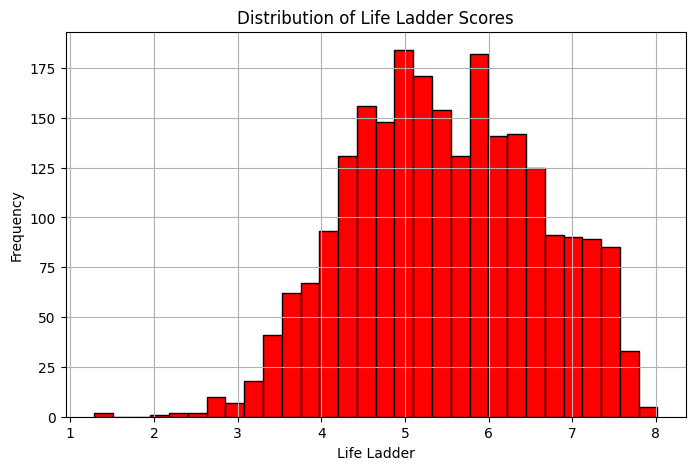

In [28]:
# Your code here:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
file_path = "https://raw.githubusercontent.com/Hamed-Ahmadinia/DASP-2025/main/World-happiness-report-updated_2024.csv"
df = pd.read_csv(file_path, encoding='latin1')

# Plot histogram using matplotlib
plt.figure(figsize=(8, 5))
plt.hist(df['Life Ladder'].dropna(), bins=30, color='red', edgecolor='black')
plt.title('Distribution of Life Ladder Scores')
plt.xlabel('Life Ladder')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()




### **Question 2: Create a scatter plot of 'Log GDP per capita' vs 'Life Ladder'**
#### Hint: Use sns.scatterplot(x=..., y=...) or plt.scatter()

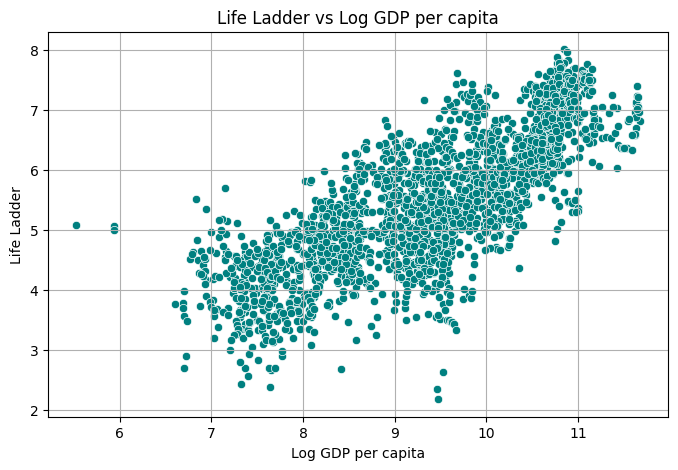

In [8]:
# Your code here:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Log GDP per capita', y='Life Ladder', data=df, color='teal')
plt.title('Life Ladder vs Log GDP per capita')
plt.xlabel('Log GDP per capita')
plt.ylabel('Life Ladder')
plt.grid(True)
plt.show()


### **Question 3: Create a box plot to show distribution of 'Life Ladder' by 'year'**
#### Hint: Use sns.boxplot(x='Regional indicator', y='Life Ladder', data=df) and rotate x-labels for readability

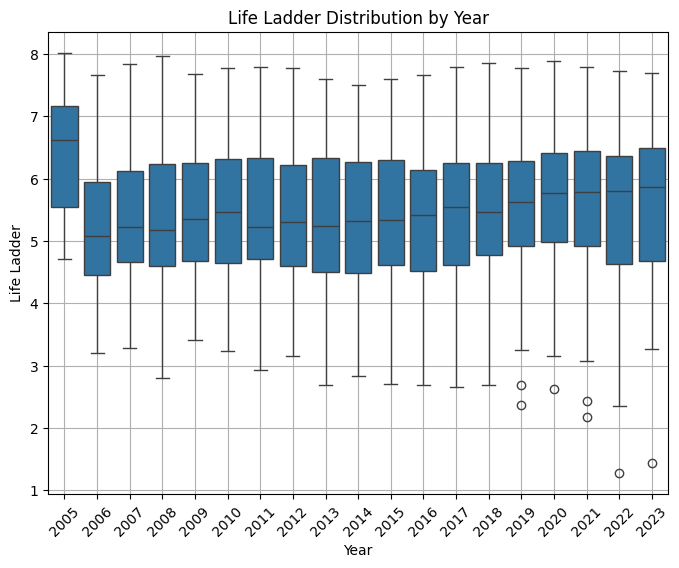

In [27]:
# Your code here:
plt.figure(figsize=(8, 6))
sns.boxplot(x='year', y='Life Ladder', data=df)
plt.title('Life Ladder Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Life Ladder')
plt.xticks(rotation=45) 
plt.grid(True)
plt.show()


### **Question 4: Create a heatmap to show correlation between numerical features**
#### Hint: Use df.corr() to calculate correlation matrix, then sns.heatmap()

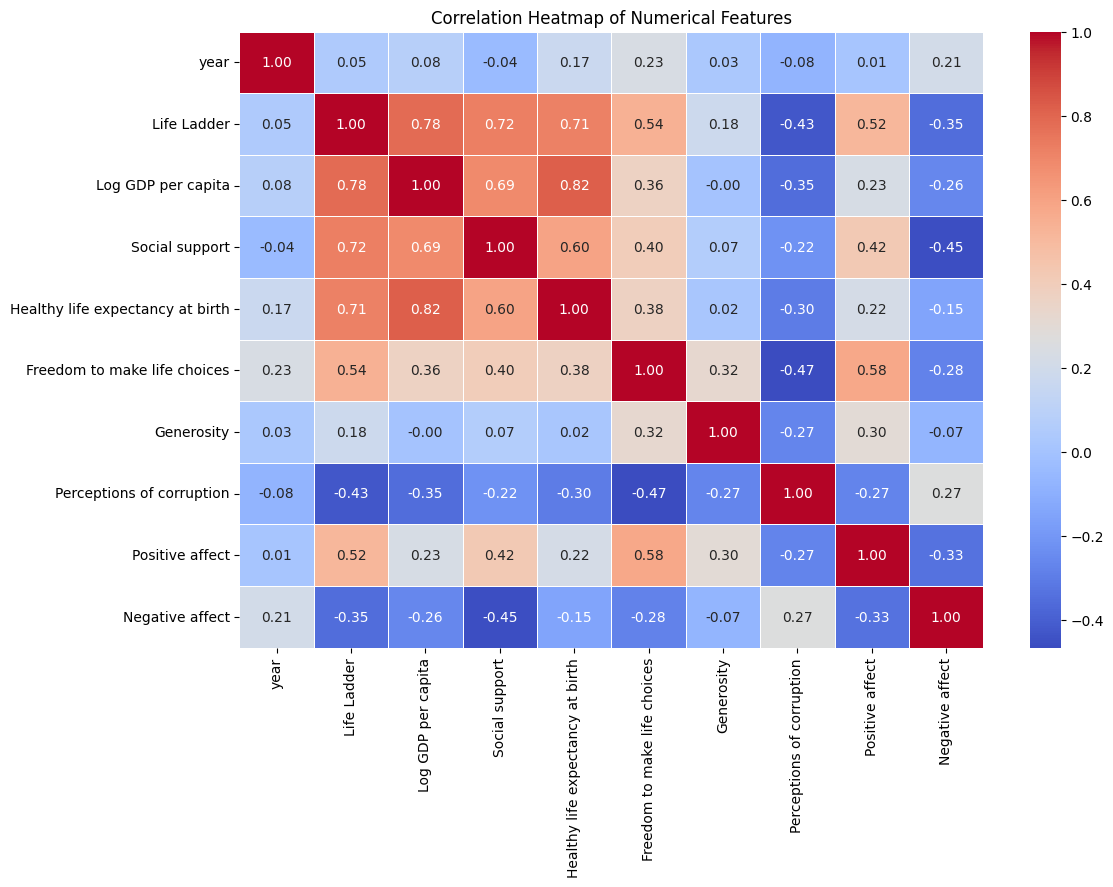

In [12]:
# Your code here:
# Select only numeric columns for correlation calculation
numeric_columns = df.select_dtypes(include=[np.number])

# Calculate the correlation matrix
corr_matrix = numeric_columns.corr()

# Create a heatmap to show correlations
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()



### **Question 5: Create a residual plot for 'Life Ladder' prediction using 'Log GDP per capita'**
#### Hint: Use LinearRegression to predict, then subtract predictions from actuals and plot with plt.scatter()

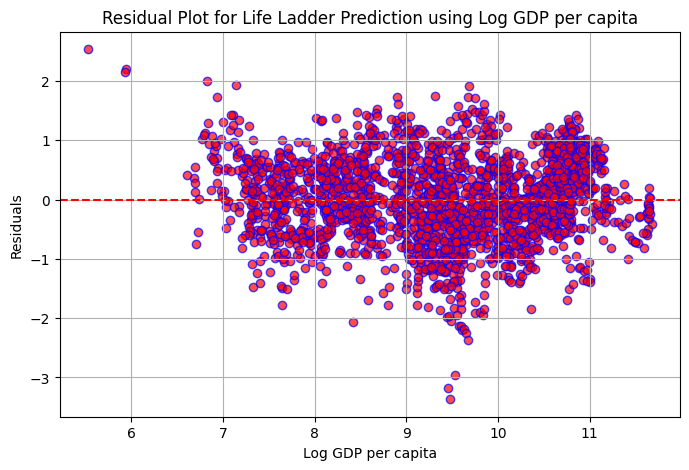

In [16]:
# Remove rows with missing values in 'Log GDP per capita' or 'Life Ladder'
df_clean = df.dropna(subset=['Log GDP per capita', 'Life Ladder'])

# Predictor variable (Log GDP per capita)
X = df_clean[['Log GDP per capita']]

y = df_clean['Life Ladder']

model = LinearRegression()
model.fit(X, y)

predictions = model.predict(X)

residuals = y - predictions

plt.figure(figsize=(8, 5))
plt.scatter(X, residuals, color='red', edgecolors='blue', alpha=0.7)
plt.axhline(0, color='red', linestyle='--')  # Adding a line at y=0 for reference
plt.title('Residual Plot for Life Ladder Prediction using Log GDP per capita')
plt.xlabel('Log GDP per capita')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()


### **Question 6: Create a line plot showing 'Healthy life expectancy at birth' over years for top 5 countries**
#### Hint: Group by 'Country name', take top 5 by average life expectancy, then use sns.lineplot() to show trends over time

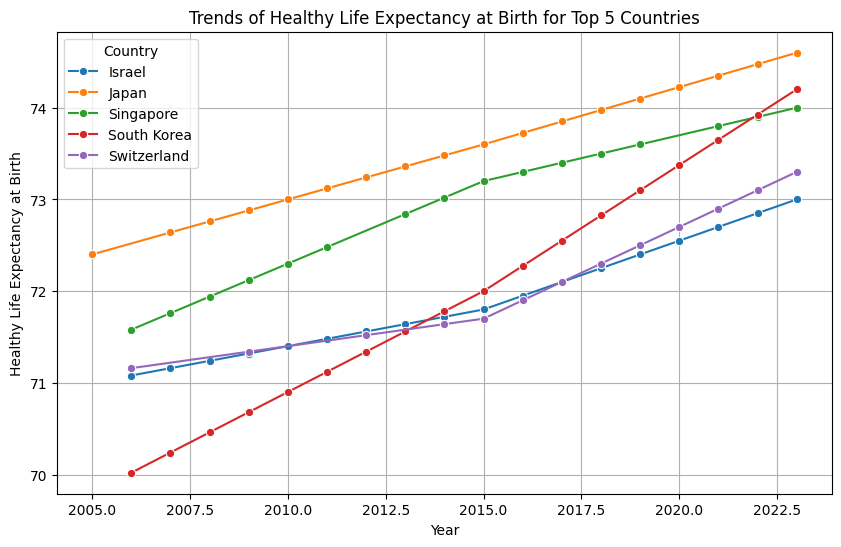

In [25]:
# Your code here:
# Group by 'Country name' and calculate the average healthy life expectancy
avg_life_expectancy = df.groupby('Country name')['Healthy life expectancy at birth'].mean().sort_values(ascending=False)

top_5_countries = avg_life_expectancy.head(5).index

# Filter the original dataframe for these top 5 countries
df_top_5 = df[df['Country name'].isin(top_5_countries)]

plt.figure(figsize=(10, 6))
sns.lineplot(x='year', y='Healthy life expectancy at birth', hue='Country name', data=df_top_5, marker='o')

plt.title('Trends of Healthy Life Expectancy at Birth for Top 5 Countries')
plt.xlabel('Year')
plt.ylabel('Healthy Life Expectancy at Birth')
plt.legend(title='Country', loc='best')
plt.grid(True)
plt.show()


### **Question 7: Create a bar chart of average 'Social support' for top 10 countries in 2023**
#### Hint: Filter the dataset for 2023, group by 'Country name', then plot the top 10 using bar chart

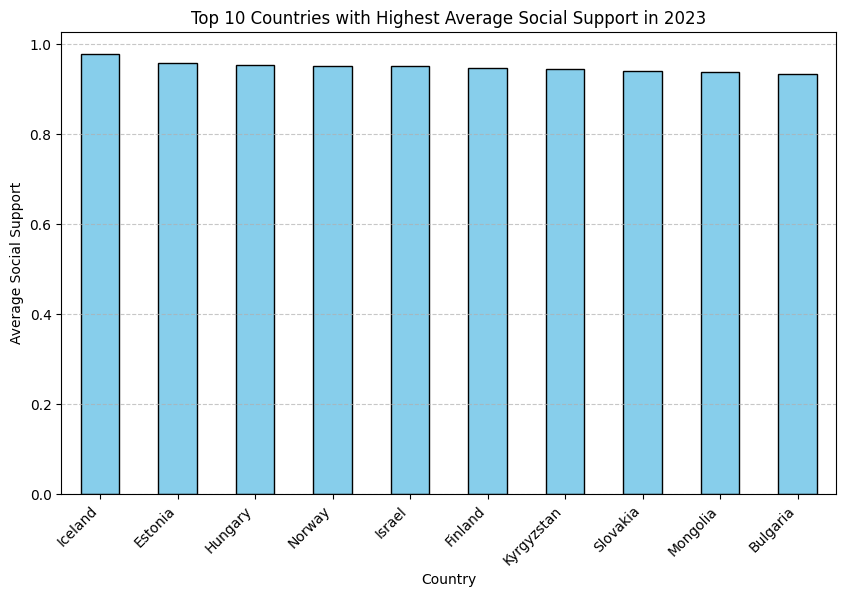

In [18]:
# Your code here:
df_2023 = df[df['year'] == 2023]

avg_social_support = df_2023.groupby('Country name')['Social support'].mean().sort_values(ascending=False)

top_10_countries = avg_social_support.head(10)

# Plot the bar chart
plt.figure(figsize=(10, 6))
top_10_countries.plot(kind='bar', color='skyblue', edgecolor='black')

# Add titles and labels
plt.title('Top 10 Countries with Highest Average Social Support in 2023')
plt.xlabel('Country')
plt.ylabel('Average Social Support')
plt.xticks(rotation=45, ha='right') 
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()


### **Question 8: Create a pie chart showing proportion of 'Country name' in the dataset (top 10 countries)**
#### Use df['Country name'].value_counts().head(10) and plt.pie() to show the most frequently appearing countries

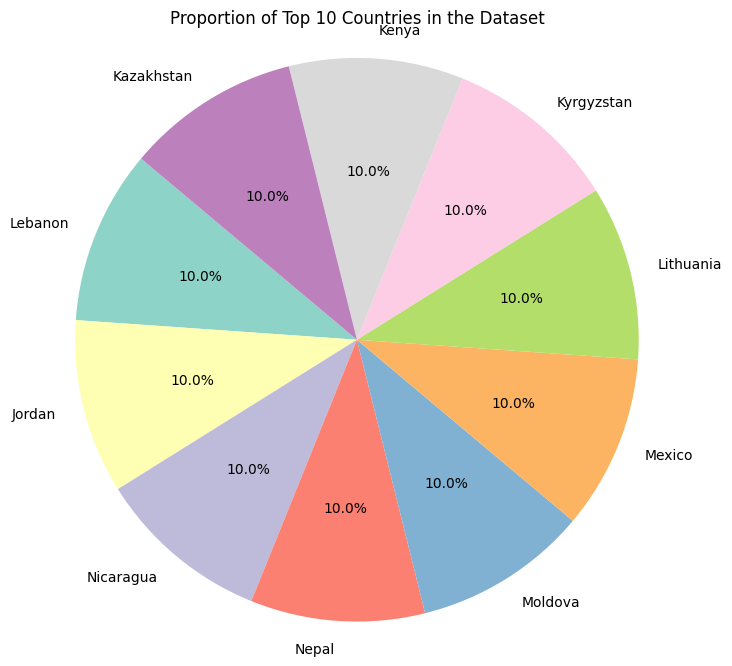

In [19]:
# Your code here:
top_10_countries = df['Country name'].value_counts().head(10)

# Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(top_10_countries, labels=top_10_countries.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set3", len(top_10_countries)))
plt.title('Proportion of Top 10 Countries in the Dataset')
plt.axis('equal')  
plt.show()


### **Question 9: Perform Linear Regression to predict 'Life Ladder' using multiple predictors**
#### Hint: Use 'Log GDP per capita', 'Social support', and 'Healthy life expectancy at birth' as X variables and fit a model

In [24]:
# Import necessary libraries
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X = df[['Log GDP per capita', 'Social support', 'Healthy life expectancy at birth']] 
y = df['Life Ladder']  

df_clean = df.dropna(subset=['Log GDP per capita', 'Social support', 'Healthy life expectancy at birth', 'Life Ladder'])

X_clean = df_clean[['Log GDP per capita', 'Social support', 'Healthy life expectancy at birth']]
y_clean = df_clean['Life Ladder']

X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the results
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


Mean Squared Error (MSE): 0.4084798927351285
R² Score: 0.6890288817718561
Coefficients: [0.38062461 3.13553993 0.03272949]
Intercept: -2.711453762592793


### **Question 10: Plot residuals from the model above**
#### Hint: Subtract predicted values from actual 'Life Ladder', then plot residuals vs predictions using plt.scatter()

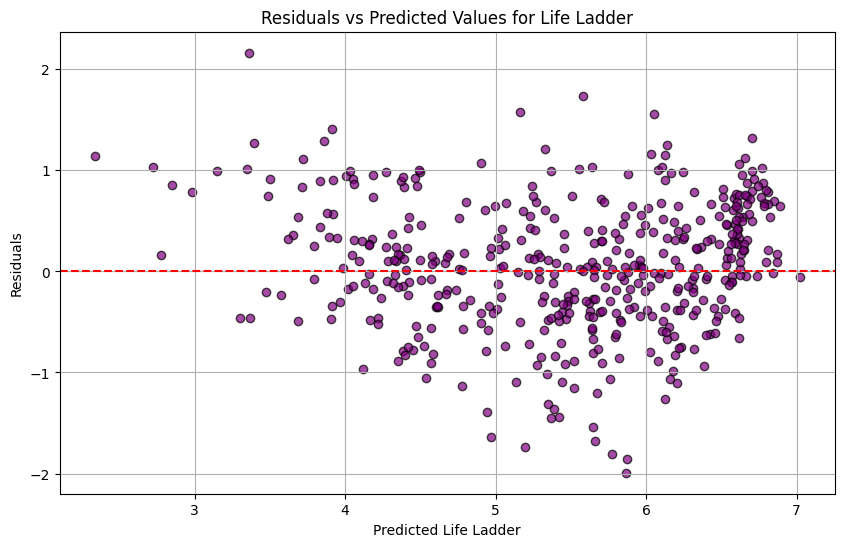

In [23]:
# Your code here:
# Calculate the residuals (actual - predicted)
residuals = y_test - y_pred

# Plot residuals vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, color='purple', edgecolors='black', alpha=0.7)
plt.axhline(0, color='red', linestyle='--') 
plt.title('Residuals vs Predicted Values for Life Ladder')
plt.xlabel('Predicted Life Ladder')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()
